# Digital Signals Theory

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from IPython.display import display, Audio

import matplotlib as mpl

mpl.rcParams['axes.spines.left'] = False
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.bottom'] = False

mpl.rcParams['axes.facecolor'] = '#f7f7f7'
mpl.rcParams['ytick.left'] = False
mpl.rcParams['xtick.bottom'] = False

## Chapter 6: Properties of the DFT

----

### 6.4 Spectral Leakage and Windowing

Given

> ... a wave $x[n]$ at frequency $f=79$, with sampling rate $f_{s}=1000$
> and duration of 1/4 second (i.e., $N = \frac{f_{s}}{4}$)...

> To illustrate the point, here we'll construct a pure sinusoid at $f = \cancel{111} 79$, with $f_{s} = 1000$, and sample for $\frac{1}{4}$ second (i.e., $N = \frac{f_s}{4} = 250$, adding a bit more to make a point)

In [2]:
fs = 1000
N = fs // 4
f = 79

t = np.arange(N) / fs

ext_t = np.arange(t[-1]+t[1], 0.35, t[1])

x = np.cos(2 * np.pi * f * t)

In [3]:
X = np.fft.fft(x)
magnitudes = np.abs(X)

freqs = np.fft.fftfreq(magnitudes.size, d=1/fs)

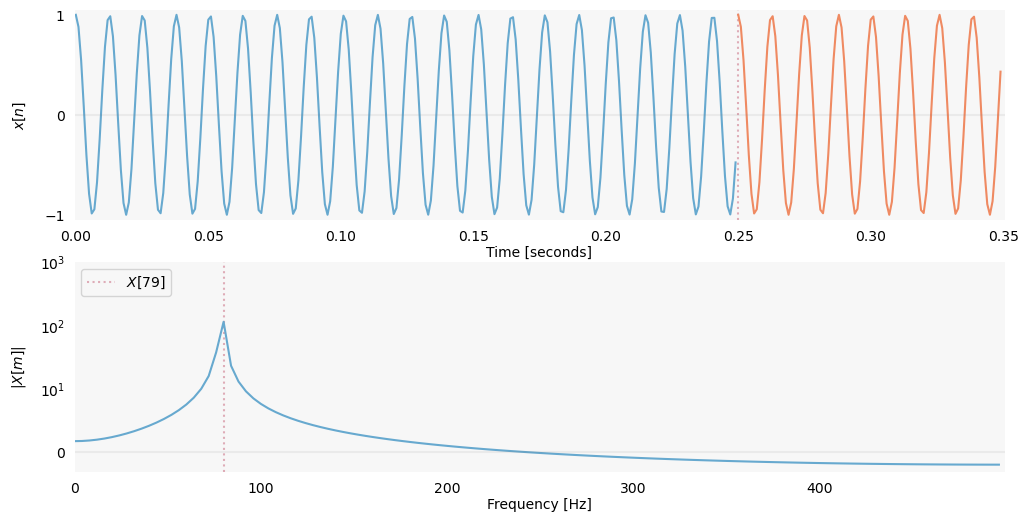

In [4]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 6))

# 1st plot for x in Time domain...
axes[0].plot(t, x, color='#67a9cf', zorder=-1)
axes[0].plot(ext_t, x[:len(ext_t)], color='#ef8a62', zorder=-1)
axes[0].axhline(y=0, color='grey', alpha=0.1)
axes[0].axvline(0.25, linestyle=':', color='#a50026', alpha=0.3, zorder=-10)
axes[0].set_xlim(-0.0005, 0.3505)
axes[0].set_yticks([-1., 0., 1.])
axes[0].set_ylim(bottom=-1.05, top=1.05)

axes[0].set_ylabel('$x[n]$')
axes[0].yaxis.set_label_coords(-0.05, 0.5)

axes[0].set_xlabel('Time [seconds]')
axes[0].xaxis.set_label_coords(0.5, -0.12)

# 2nd plot for Frequency domain...
axes[1].plot(freqs[:125], np.log10(magnitudes[:125]), color='#67a9cf', zorder=-1)
axes[1].axhline(y=0, color='grey', alpha=0.1)
axes[1].axvline(f+1, linestyle=':', color='#a50026', alpha=0.3, zorder=-10, label='$X[79]$')
axes[1].legend(loc='upper left')
axes[1].set_xlim(0, 499)

# Move left y-axis, passing through (0,0)
axes[1].spines['left'].set_position('zero')
axes[1].set_yticks([0, 1, 2, 3 ], ['0', '$10^1$', '$10^2$', '$10^3$'])
axes[1].set_ylabel('$| X[m] |$')
axes[1].yaxis.set_label_coords(-0.05, 0.5)

axes[1].set_xlabel('Frequency [Hz]')
axes[1].xaxis.set_label_coords(0.5, -0.12)

plt.show()

Repeating this non-analysis frequency $f=79$ produces discontinuities when the signal repeats. 

These discontinuities are audible as _clicks_ or _pops_.

In the example below, we repeat the signal 8 times, so you will hear 8 _clicks_. Or more like _knocks_.

In [5]:
import scipy.signal

t = np.arange(N) / fs
x = np.tile(np.cos(2 * np.pi * f * t), 8)

y = scipy.signal.resample(x, 8 * len(x))

display('Listen to this...!')
display(Audio(data=y, rate=8*fs))

'Listen to this...!'

#### 6.4.1 Windowing

> In (the following code) we have traded off transient discontinuities for a smoothly varying pulse,
> which cna be more easily modeled by sinusoids...

In [6]:
t = np.arange(N) / fs
w = scipy.signal.get_window('hann', N, fftbins=False)

x = np.cos(2 * np.pi * f * t)
x = np.tile(x*w, 8)

y = scipy.signal.resample(x, 8 * len(x))

display('... and now, it is smoothed with low frequency modulation...')
display(Audio(data=y, rate=8*fs))

'... and now, it is smoothed with low frequency modulation...'

----

### 6.5 Exercises

#### Exercise 6.1

In general, magnitude is not a linear operation for complex numbers: $\left| w + z \right| \neq |w| + |z|$.

* _Are there any special case wher this equality holds?_
* _If so, what general property must those numbers satisfy to ensure that equality holds?_


From the Triangle Inequality, we know that:

\begin{flalign}
\qquad \left| w + z \right| &\leq |w| + |z|  & \\\\
\end{flalign}

... and that only in the case that the triangle is degenerate (the three points are collinear) will the following equality will hold:

\begin{flalign}
\qquad \left| w + z \right| &= |w| + |z|  & \\\\
\end{flalign}

This case can only occur when either $w$ or $z$ is 0.

----

#### Exercise 6.2

On the DFT shifting theorem...

* For a fixed frequency index $m$ and signal length $N$, can you find a delay $d \in \{ 0, N \}$ such that $X[m] = Y[m]$?
* That is, is there a non-trivial delay that leaves $X[m]$ unchanged?

From Theorem 6.1 (DFT shifting) on page 130 we have:

\begin{flalign}
\qquad Y[m] &= X[m] \cdot exp(-j \cdot 2\pi \cdot\frac{m}{N} \cdot d)  & \\\\
\end{flalign}

... and we can see that $X[m] = Y[m]$ only when:

\begin{flalign}
\qquad exp(-j \cdot 2\pi \cdot\frac{m}{N} \cdot d) &= 1   & \\\\
\end{flalign}

That can only occur if for all $k$ that are factors of $m$, $d = \frac{N}{k}$ when $N \text{ mod } d = 0$.

1. $d = 0$ is trivial; there is no DFT shifting at all, so of course $X[m] = Y[m]$.
2. $d = N$ is also trivial; we shift exactly 1 whole cycle, and again, $X[m] = Y[m]$ naturally.
3. but for $k \in { \text{ all factors of } m }$, if we let $d = \frac{N}{k}$ _and_ $N \text{ mod } d = 0$, then we have another case where $X[m] = Y[m]$.

##### Example: $m = 15$ and $N = 60$

Letting $k \in {1, 3, 5, 15}$

\begin{flalign}
\qquad exp(-j \cdot 2\pi \cdot\frac{m}{N} \cdot d) &= 1   & \\\\
\end{flalign}

----

#### Exercise 6.3

On the DFT of time-reversed signals...

Given $y[n] = x[N-n]$ is the time-reversal of $x[n]$, what can we say about how DFT $Y[m]$ relates to $X[m]$?

_... intuitively, the DFT should look the same since by definition the time-domain information is lost/ignored in a DFT._

In [7]:
from scipy.signal import windows, sawtooth

fs = 1000
N = fs // 4
f = 79

t = np.arange(N) / fs

# set up ufor x[n] and X[m]...
x = sawtooth(2*np.pi * f * t)
X = np.fft.rfft(x)
mag_X = np.abs(X)

freq_idx = np.arange(X.size)

# set up for time-reversed y[n] = x[N-n] and corresponding Y[m]...
y = x[::-1]
Y = np.fft.rfft(y)
mag_Y = np.abs(Y)

signals = [
    {'x_title': 'Sawtooth signal $x[n]$', 'X_title': '$X[m]$',  'x': x, 'X': mag_X},
    {'x_title': '$y[n]$ ($x[N-n]$)', 'X_title': '$Y[m]$', 'x': y, 'X': mag_Y},
]

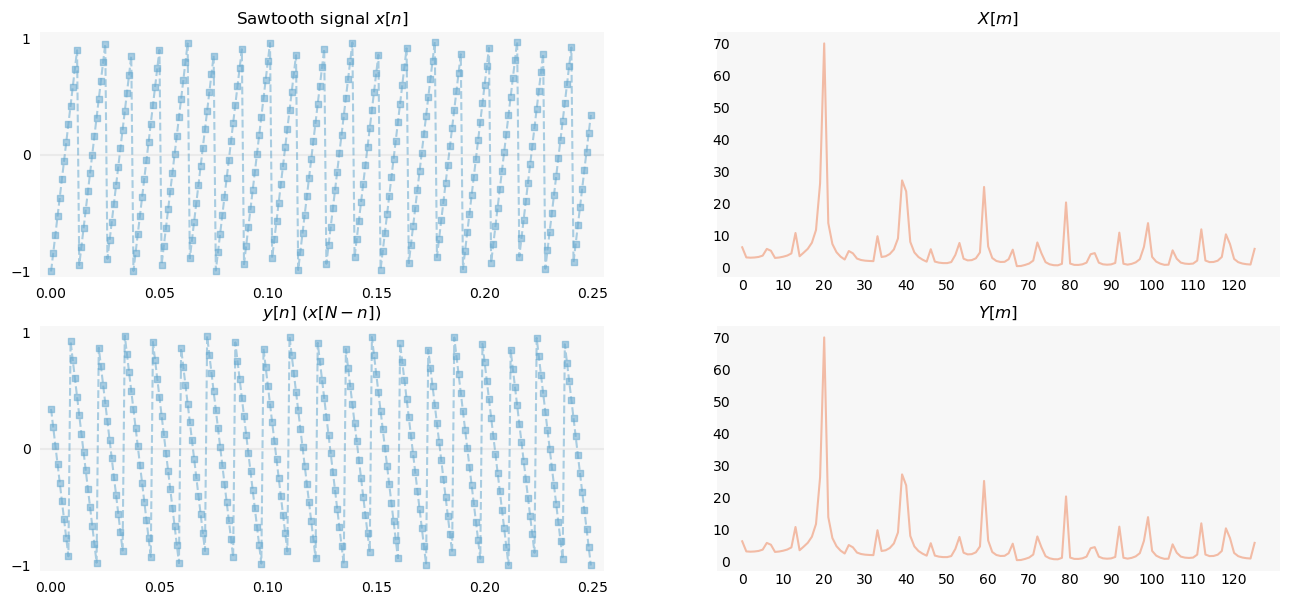

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 7))

for i,signal in enumerate(signals):

    # 1st plot for x in Time domain...
    axes[i,0].scatter(t, signal['x'], color='#67a9cf', marker='s', s=18.0, alpha=0.55, zorder=-1)
    axes[i,0].plot(t, signal['x'], color='#67a9cf', linestyle='--', alpha=0.55, zorder=-1)
    
    axes[i,0].grid(False)
    axes[i,0].set_title(signal['x_title'])
    axes[i,0].axhline(y=0, color='grey', alpha=0.1)

    axes[i,0].set_xlim(-0.005, 0.255)
    axes[i,0].set_ylim(bottom=-1.05, top=1.05)
    axes[i,0].set_yticks([-1., 0, 1.])


    # -----------------------------------
    # 2nd plot for the corresponding DFT
    axes[i,1].plot(freq_idx, signal['X'], color='#ef8a62', alpha=0.55)
    
    axes[i,1].grid(False)
    axes[i,1].set_title(signal['X_title'])
    # Eliminate upper and right axes
    axes[i,1].spines['right'].set_color('none')
    axes[i,1].spines['top'].set_color('none')
    axes[i,1].spines['bottom'].set_color('none')
    
    # Move left y-axis, passing through (0,0)
    axes[i,1].spines['left'].set_position('zero')
    axes[i,1].spines['left'].set_color('grey')
    axes[i,1].spines['left'].set_alpha(0.4)
    axes[i,1].tick_params(axis='y', which=u'both', length=5, color='#96969680')
    
    # Move bottom x-axis, passing through center of plot
    axes[i,1].spines['bottom'].set_position('zero')
    axes[i,1].spines['bottom'].set_color('grey')
    axes[i,1].spines['bottom'].set_alpha(0.4)
    axes[i,1].set_xticks(np.arange(0, N//2 + 1, 10))
    axes[i,1].tick_params(axis='x', which=u'both', length=5, color='#96969680')

#plt.suptitle(f'$x[n]$ / $X[m]$ and $y[n]$ / $Y[m]$')
plt.show()

----

#### Exercise 6.4



In [9]:
import soundfile

fin = 'bin/334534__teddy_frost__piano-a4-sound.wav'
fin_info = soundfile.info(fin)
print(fin_info)

bin/334534__teddy_frost__piano-a4-sound.wav
samplerate: 44100 Hz
channels: 2
duration: 2.245 s
format: WAV (Microsoft) [WAV]
subtype: Signed 16 bit PCM [PCM_16]


In [10]:
stereo_x, fs = soundfile.read(fin)
mono_x = stereo_x[:,0]/2 + stereo_x[:,1]/2

N = int(fin_info.samplerate * fin_info.duration)
t = np.arange(N) / fin_info.samplerate

display('A4 on a piano')
display(Audio(data=mono_x, rate=fin_info.samplerate))

'A4 on a piano'

In [11]:
# no windowing
w_nowindow = np.ones(N)
x_nowindow = mono_x
X_nowindow = np.fft.rfft(x_nowindow)
max_X_nowindow = np.abs(X_nowindow)

freq_idx = np.arange(X_nowindow.size)

# Hann window
w_hann = windows.hann(len(mono_x), sym=False)
x_hann = mono_x * w_hann
X_hann = np.fft.rfft(x_hann)
mag_X_hann = np.abs(X_hann)

# Hamming window
w_hamming = windows.hamming(len(mono_x), sym=False)
x_hamming = mono_x * w_hamming
X_hamming = np.fft.rfft(x_hamming)
mag_X_hamming = np.abs(X_hamming)

# triangle window
w_triang = windows.triang(len(mono_x), sym=False)
x_triang = mono_x * w_triang
X_triang = np.fft.rfft(x_triang)
mag_X_triang = np.abs(X_triang)

# Kaiser window (beta=14)
w_kaiser = windows.kaiser(len(mono_x), beta=14, sym=False)
x_kaiser = mono_x * w_kaiser
X_kaiser= np.fft.rfft(x_kaiser)
mag_X_kaiser = np.abs(X_kaiser)

# Blackman-Harris window
w_blackmanharris = windows.blackmanharris(len(mono_x), sym=False)
x_blackmanharris= mono_x * w_blackmanharris
X_blackmanharris = np.fft.rfft(x_blackmanharris)
mag_X_blackmanharris = np.abs(X_blackmanharris)


signals = [
    {'label': 'no window', 'x': x_nowindow, 'w': w_nowindow, 'X': max_X_nowindow},
    {'label': 'Hann', 'x': x_hann, 'w': w_hann, 'X': mag_X_hann},    
    {'label': 'Hamming', 'x': x_hamming, 'w': w_hamming, 'X': mag_X_hamming},   
    {'label': 'triangle', 'x': x_triang, 'w': w_triang, 'X': mag_X_triang},  
    {'label': 'Kaiser', 'x': x_kaiser, 'w': w_kaiser, 'X': mag_X_kaiser},  
    {'label': 'Blackman-Harris', 'x': x_blackmanharris, 'w': w_blackmanharris, 'X': mag_X_blackmanharris},  
]

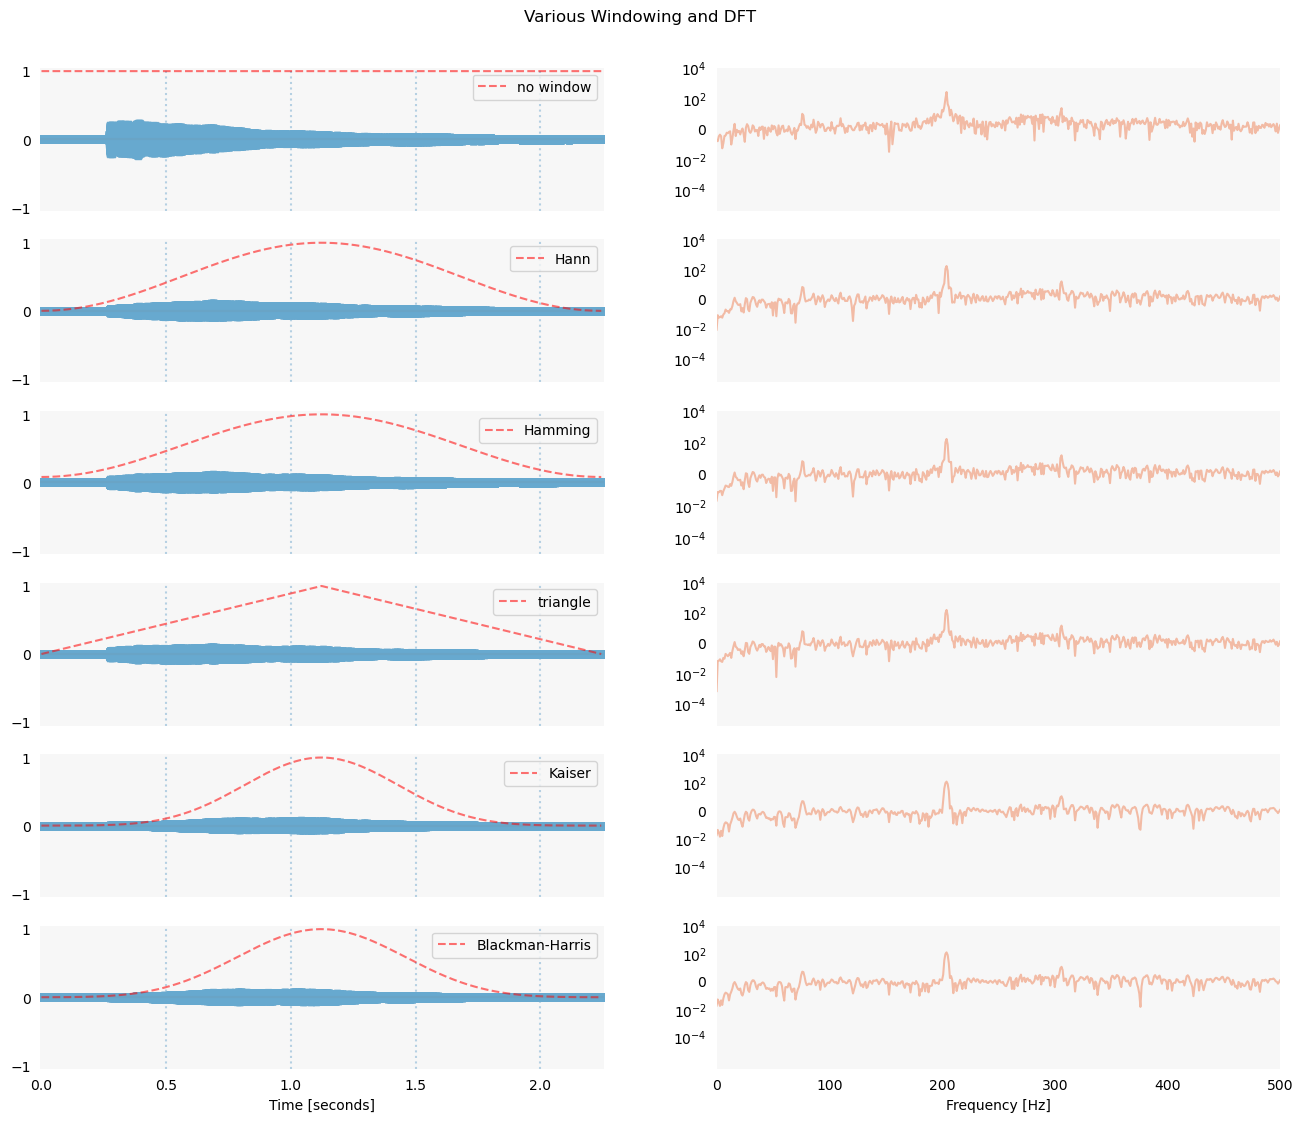

In [12]:
fig, axes = plt.subplots(nrows=len(signals), ncols=2, figsize=(16, 13))

for i,signal in enumerate(signals):

    # 1st plot for x in Time domain...
    axes[i,0].scatter(t, signal['x'], color='#67a9cf', marker='s', s=18.0, alpha=0.55, zorder=-1)
    axes[i,0].plot(t, signal['w'], color='red', linestyle='--', alpha=0.55, zorder=-1, label=signal['label'])
    axes[i,0].legend(loc='upper right')
    axes[i,0].axhline(y=0, color='grey', alpha=0.1)

    if i == len(signals)-1:
        axes[i,0].set_xlabel('Time [seconds]')
    else:
       axes[i,0].set_xticks([]) 
        
    axes[i,0].set_xlim(-0.005, 2.255)    
    axes[i,0].axvline(0.5, linestyle=':', alpha=0.3, zorder=-10)
    axes[i,0].axvline(1.0, linestyle=':', alpha=0.3, zorder=-10)
    axes[i,0].axvline(1.5, linestyle=':', alpha=0.3, zorder=-10)
    axes[i,0].axvline(2.0, linestyle=':', alpha=0.3, zorder=-10)
    axes[i,0].set_ylim(bottom=-1.05, top=1.05)
    axes[i,0].set_yticks([-1., 0, 1.])

    # -----------------------------------
    # 2nd plot for the corresponding DFT
    axes[i,1].plot(freq_idx, np.log10(signal['X']), color='#ef8a62', alpha=0.55)

    if i == len(signals)-1:
        axes[i,1].set_xlabel('Frequency [Hz]')
    else:
        axes[i,1].set_xticks([]) 

    
    axes[i,1].set_xlim(-0.005, 500)
    axes[i,1].set_yticks([-4, -2, 0, 2, 4 ], ['$10^{{-4}}$', '$10^{{-2}}$', '$0$', '$10^2$', '$10^4$'])

plt.suptitle('Various Windowing and DFT', y=0.925)
plt.show()